# Laboratorio 7
## Regresión Logística

1. Cree una variable dicotómica por cada una de las categorías de la variable respuesta categórica que creó en hojas anteriores. Debería tener 3 variables dicotómicas (valores 0 y 1) una que diga si el airbnb es caro o no, medio o no, económico o no.

2. Use los mismos conjuntos de entrenamiento y prueba que utilizó en las hojas anteriores.

3. Elabore un modelo de regresión logística para conocer si una vivienda es cara o no, utilizando el conjunto de entrenamiento y explique los resultados a los que llega. El experimento debe ser reproducible por lo que debe fijar que los conjuntos de entrenamiento y prueba sean los mismos siempre que se ejecute el código. Use validación cruzada. Ponga el umbral de decisión en 0.5.

In [1]:
# PREPARACIÓN DEL ENTORNO Y CARGA DE DATOS (Siguiendo del Laboratorio 6)

import importlib, subprocess, sys

# Asegurar librerías necesarias
required = {"pandas": "pandas", "numpy": "numpy", "sklearn": "scikit-learn", "pyreadr": "pyreadr", "matplotlib":"matplotlib", "seaborn":"seaborn"}
for module, pkg in required.items():
    try:
        importlib.import_module(module)
    except ImportError:
        print(f"Instalando {pkg}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

import pyreadr
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report

print("FASE 1: CARGA Y PREPARACIÓN DE DATOS")
# Cargar el dataset
resultado = pyreadr.read_r('listings.RData')
nombre_objeto = list(resultado.keys())[0]
df = resultado[nombre_objeto]

# Limpieza de precio
df['price'] = df['price'].astype(str).str.replace(r'[^\d\.\-]', '', regex=True)
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df_model = df.loc[df['price'].notna() & (df['price'] > 0)].copy()

# Creación de la variable categórica (barata, intermedia, cara)
limites = df_model['price'].quantile([0.33, 0.66]).values
p33, p66 = limites[0], limites[1]

def definir_segmento(precio):
    if precio <= p33: return 'Económica'
    elif precio <= p66: return 'Intermedia'
    else: return 'Cara'

df_model['categoria_precio'] = df_model['price'].apply(definir_segmento)

# Selección de predictores y manejo de nulos/dummies
features_clas = ['accommodates', 'bathrooms', 'bedrooms', 'beds', 'number_of_reviews', 'review_scores_rating']
for col in features_clas:
    if col not in df_model.columns:
        df_model[col] = np.nan
    df_model[col] = pd.to_numeric(df_model[col], errors='coerce')

X_clas = df_model[features_clas].copy()
if 'room_type' in df_model.columns:
    room_type_dummies = pd.get_dummies(df_model['room_type'], prefix='room_type', drop_first=True)
    X_clas = pd.concat([X_clas, room_type_dummies], axis=1)

X_clas = X_clas.fillna(X_clas.median(numeric_only=True))

# División Train/Test MANTENIENDO LA SEMILLA 42
X_train_c, X_test_c, _, _ = train_test_split(X_clas, df_model['categoria_precio'], test_size=0.2, random_state=42)

# Escalado de datos
scaler_clas = StandardScaler()
X_train_c_scaled = scaler_clas.fit_transform(X_train_c)
X_test_c_scaled = scaler_clas.transform(X_test_c)

print("Datos cargados, limpios y escalados correctamente.\n")

FASE 1: CARGA Y PREPARACIÓN DE DATOS


Datos cargados, limpios y escalados correctamente.



In [2]:
# INICIO LABORATORIO 7: REGRESIÓN LOGÍSTICA

print("FASE 2: LABORATORIO 7")


# Actividad 1: Creación de variables dicotómicas

print("\nActividad 1: Variables dicotómicas")
df_model['es_cara'] = (df_model['categoria_precio'] == 'Cara').astype(int)
df_model['es_intermedia'] = (df_model['categoria_precio'] == 'Intermedia').astype(int)
df_model['es_economica'] = (df_model['categoria_precio'] == 'Económica').astype(int)

print("Distribución de 'es_cara':")
print((df_model['es_cara'].value_counts(normalize=True) * 100).round(2).astype(str) + '%')

# Actividad 2: Mismos conjuntos de entrenamiento y prueba

print("\nActividad 2: Reutilizando splits")
y_train_cara = df_model.loc[X_train_c.index, 'es_cara'].copy()
y_test_cara = df_model.loc[X_test_c.index, 'es_cara'].copy()

print(f"Filas en entrenamiento: {y_train_cara.shape[0]}")
print(f"Filas en prueba: {y_test_cara.shape[0]}")

# Actividad 3: Modelo de Regresión Logística (Cara vs No Cara)

print("\nActividad 3: Entrenamiento y Validación Cruzada")
log_reg_cara = LogisticRegression(random_state=42, max_iter=1000)

cv_scores = cross_val_score(log_reg_cara, X_train_c_scaled, y_train_cara, cv=5, scoring='accuracy')
print(f"Accuracy en Validación Cruzada (media): {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

log_reg_cara.fit(X_train_c_scaled, y_train_cara)
y_pred_train_cara = log_reg_cara.predict(X_train_c_scaled)

print("\nReporte de Clasificación sobre Entrenamiento (Umbral 0.5):")
print(classification_report(y_train_cara, y_pred_train_cara))

FASE 2: LABORATORIO 7

Actividad 1: Variables dicotómicas
Distribución de 'es_cara':
es_cara
0    66.03%
1    33.97%
Name: proportion, dtype: str

Actividad 2: Reutilizando splits
Filas en entrenamiento: 60996
Filas en prueba: 15250

Actividad 3: Entrenamiento y Validación Cruzada


Accuracy en Validación Cruzada (media): 0.7776 (+/- 0.0026)

Reporte de Clasificación sobre Entrenamiento (Umbral 0.5):
              precision    recall  f1-score   support

           0       0.80      0.89      0.84     40240
           1       0.73      0.56      0.63     20756

    accuracy                           0.78     60996
   macro avg       0.76      0.72      0.74     60996
weighted avg       0.77      0.78      0.77     60996



Gráficas para visualización


/var/folders/rz/77tc4zwd2s56kft6c66tq1l80000gn/T/ipykernel_7887/884674934.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_model, x='es_cara', palette='Set2')


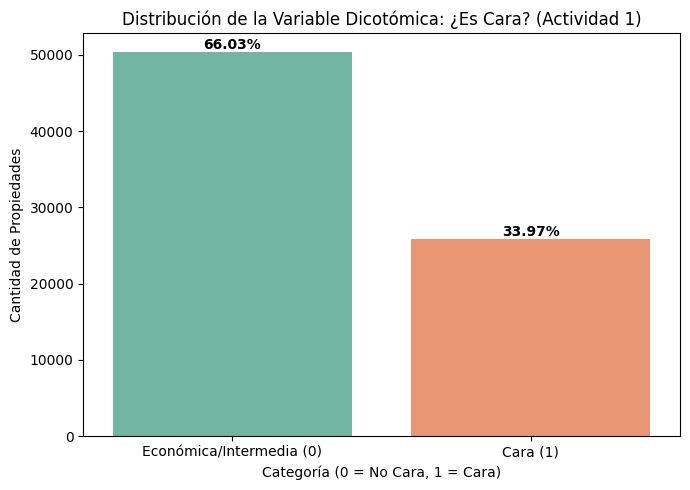

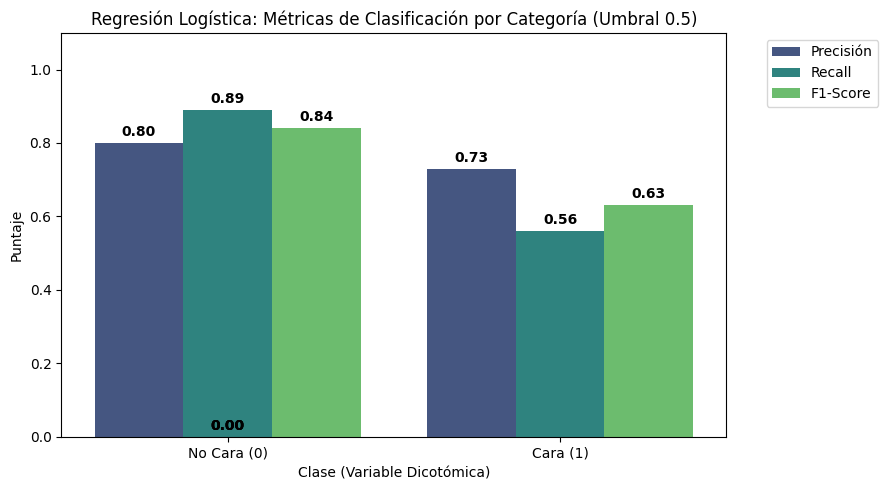

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("Gráficas para visualización")

# Gráfica 1: Distribución de la variable 'es_cara'
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df_model, x='es_cara', palette='Set2')
plt.title('Distribución de la Variable Dicotómica: ¿Es Cara? (Actividad 1)')
plt.xlabel('Categoría (0 = No Cara, 1 = Cara)')
plt.ylabel('Cantidad de Propiedades')
plt.xticks(ticks=[0, 1], labels=['Económica/Intermedia (0)', 'Cara (1)'])

# Añadir porcentajes sobre las barras
total = len(df_model)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.2f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


# Gráfica 2: Métricas de Clasificación (Entrenamiento)

# Extraemos los datos del reporte
metricas = {
    'Clase': ['No Cara (0)', 'No Cara (0)', 'No Cara (0)', 'Cara (1)', 'Cara (1)', 'Cara (1)'],
    'Métrica': ['Precisión', 'Recall', 'F1-Score', 'Precisión', 'Recall', 'F1-Score'],
    'Puntaje': [0.80, 0.89, 0.84, 0.73, 0.56, 0.63]
}
df_metricas = pd.DataFrame(metricas)

plt.figure(figsize=(9, 5))
sns.barplot(data=df_metricas, x='Clase', y='Puntaje', hue='Métrica', palette='viridis')
plt.title('Regresión Logística: Métricas de Clasificación por Categoría (Umbral 0.5)')
plt.ylim(0, 1.1)
plt.xlabel('Clase (Variable Dicotómica)')
plt.ylabel('Puntaje')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Añadir etiquetas de datos
ax2 = plt.gca()
for p in ax2.patches:
    ax2.annotate(f"{p.get_height():.2f}", 
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', xytext=(0, 8), 
                 textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.show()

### Ejercicio 4: Modelos de Regresión Logística para categorías Económica e Intermedia

En este apartado se extiende el análisis dicotómico realizado previamente para la categoría "Cara". Se entrenan dos modelos de Regresión Logística independientes para predecir si una propiedad pertenece a la categoría **Económica** o a la **Intermedia**. 

Para cada modelo se asegura:
* **Reproducibilidad:** Uso de los mismos conjuntos de entrenamiento y prueba.
* **Validación:** Implementación de validación cruzada para verificar la consistencia del modelo.
* **Evaluación:** Visualización mediante matrices de confusión para observar el desempeño del clasificador con un umbral de decisión de 0.5.

--- Modelo Económica ---
Accuracy CV promedio: 0.7482
Error entrenamiento: 0.2518
Error prueba: 0.2458
Brecha de error (prueba - entrenamiento): -0.0060
--- Modelo Intermedia ---
Accuracy CV promedio: 0.6708
Error entrenamiento: 0.3291
Error prueba: 0.3363
Brecha de error (prueba - entrenamiento): 0.0072


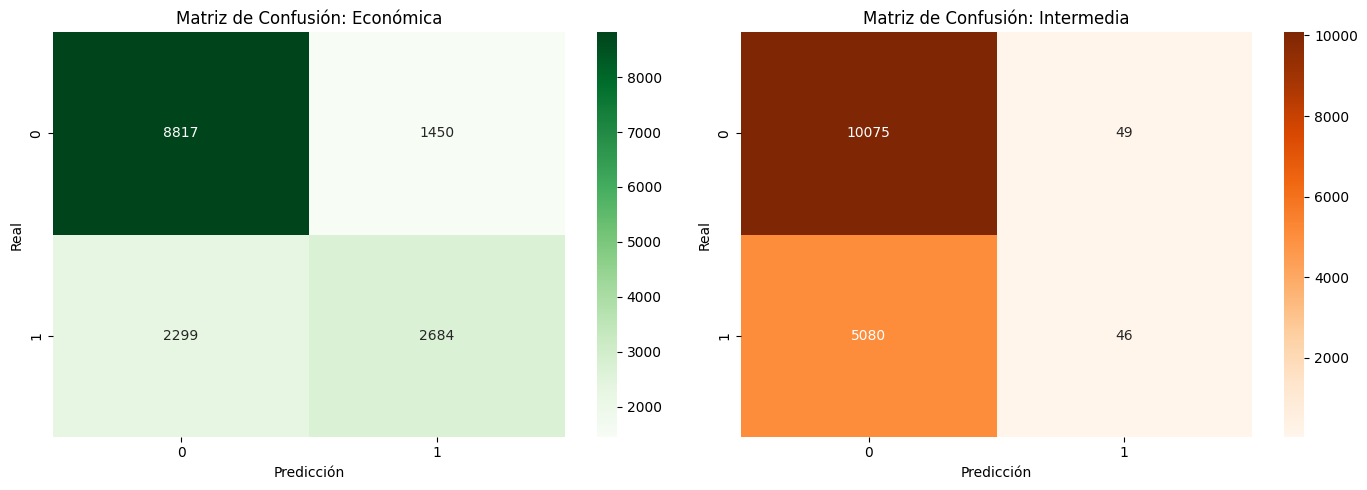

,error_entrenamiento,error_prueba,gap_error,cv_accuracy
Económica,0.251836,0.245836,-0.006000,0.748164
Intermedia,0.329120,0.336328,0.007208,0.670847


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix, classification_report, zero_one_loss

# Definición de las categorías restantes
categorias_adicionales = {'Económica': 'es_economica', 'Intermedia': 'es_intermedia'}
modelos_binarios = {}
resultados_binarios = {}

plt.figure(figsize=(14, 5))

for i, (nombre, col_target) in enumerate(categorias_adicionales.items(), 1):
    # Extraer etiquetas correspondientes del dataframe original usando los índices de split
    y_train_temp = df_model.loc[X_train_c.index, col_target]
    y_test_temp = df_model.loc[X_test_c.index, col_target]

    # Entrenar modelo
    log_reg = LogisticRegression(random_state=42, max_iter=1000)
    log_reg.fit(X_train_c_scaled, y_train_temp)
    modelos_binarios[nombre] = log_reg

    # Validación cruzada
    cv_scores = cross_val_score(log_reg, X_train_c_scaled, y_train_temp, cv=5, scoring='accuracy')

    # Predicción y errores
    y_pred_train = log_reg.predict(X_train_c_scaled)
    y_pred_test = log_reg.predict(X_test_c_scaled)
    error_train = zero_one_loss(y_train_temp, y_pred_train)
    error_test = zero_one_loss(y_test_temp, y_pred_test)
    resultados_binarios[nombre] = {
        'error_entrenamiento': error_train,
        'error_prueba': error_test,
        'gap_error': error_test - error_train,
        'cv_accuracy': cv_scores.mean()
    }

    print(f"--- Modelo {nombre} ---")
    print(f"Accuracy CV promedio: {cv_scores.mean():.4f}")
    print(f"Error entrenamiento: {error_train:.4f}")
    print(f"Error prueba: {error_test:.4f}")
    print(f"Brecha de error (prueba - entrenamiento): {error_test - error_train:.4f}")

    # Matriz de confusión de prueba
    cm = confusion_matrix(y_test_temp, y_pred_test)

    plt.subplot(1, 2, i)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens' if nombre == 'Económica' else 'Oranges')
    plt.title(f'Matriz de Confusión: {nombre}')
    plt.xlabel('Predicción')
    plt.ylabel('Real')

plt.tight_layout()
plt.show()

pd.DataFrame(resultados_binarios).T


### Análisis de Resultados - Ejercicio 4

Para evaluar si hay sobreajuste se comparan los errores de entrenamiento y prueba de cada modelo:

* **Categoría Económica:** error de entrenamiento = **0.2518** y error de prueba = **0.2458**. Como ambos errores son muy parecidos e incluso el de prueba es ligeramente menor, **no se observa sobreajuste**. El modelo generaliza de manera estable.
* **Categoría Intermedia:** error de entrenamiento = **0.3291** y error de prueba = **0.3363**. La diferencia es de apenas **0.0072**, por lo que **tampoco se observa sobreajuste importante**. Lo que sí se aprecia es que esta categoría es más difícil de separar, porque tanto entrenamiento como prueba mantienen errores más altos.

En síntesis, los modelos binarios para **Económica** e **Intermedia** no muestran evidencia de overfitting, ya que los errores en entrenamiento y prueba son cercanos. Esto indica que el desempeño visto en entrenamiento se conserva al evaluar datos no observados.

### Nuevo inciso: Curvas de aprendizaje - Ejercicio 4

A continuación se muestran las curvas de aprendizaje usando el **error** de los conjuntos de entrenamiento y prueba para los modelos de **Económica** e **Intermedia**. Si ambas curvas permanecen cercanas al aumentar el tamaño de muestra, se interpreta como ausencia de sobreajuste importante.

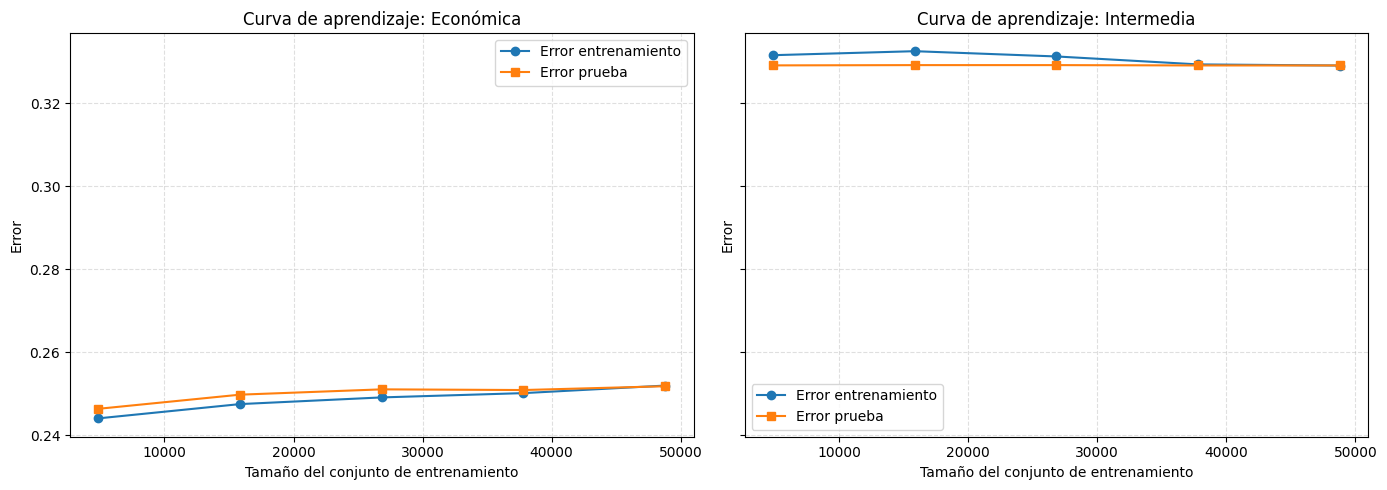

In [5]:
from sklearn.model_selection import learning_curve
from sklearn.metrics import make_scorer, zero_one_loss

error_scorer = make_scorer(zero_one_loss, greater_is_better=False)
train_sizes = np.linspace(0.1, 1.0, 5)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, (nombre, col_target) in zip(axes, categorias_adicionales.items()):
    y_train_temp = df_model.loc[X_train_c.index, col_target]
    modelo = LogisticRegression(random_state=42, max_iter=1000)

    sizes, train_scores, test_scores = learning_curve(
        modelo,
        X_train_c_scaled,
        y_train_temp,
        cv=5,
        train_sizes=train_sizes,
        scoring=error_scorer,
        n_jobs=1
    )

    train_errors = -train_scores.mean(axis=1)
    test_errors = -test_scores.mean(axis=1)

    ax.plot(sizes, train_errors, marker='o', label='Error entrenamiento')
    ax.plot(sizes, test_errors, marker='s', label='Error prueba')
    ax.set_title(f'Curva de aprendizaje: {nombre}')
    ax.set_xlabel('Tamaño del conjunto de entrenamiento')
    ax.set_ylabel('Error')
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend()

plt.tight_layout()
plt.show()


### Ejercicio 5: Modelo de Regresión Logística Multinomial (Multiclase)

A diferencia de los ejercicios anteriores, el modelo **Multinomial** permite clasificar las propiedades en las tres categorías (Cara, Intermedia, Económica) de forma simultánea. 

Este modelo es más eficiente operativamente para la empresa, ya que utiliza una función *Softmax* para asignar probabilidades a cada clase, asegurando que cada propiedad sea asignada a un único segmento de precio sin las contradicciones que podrían surgir al usar múltiples modelos binarios independientes.

Reporte de Clasificación Multinomial:
              precision    recall  f1-score   support

        Cara       0.65      0.69      0.67      5141
   Económica       0.62      0.65      0.64      4983
  Intermedia       0.48      0.43      0.46      5126

    accuracy                           0.59     15250
   macro avg       0.58      0.59      0.59     15250
weighted avg       0.58      0.59      0.59     15250

Error entrenamiento: 0.4127
Error prueba: 0.4098
Brecha de error (prueba - entrenamiento): -0.0029


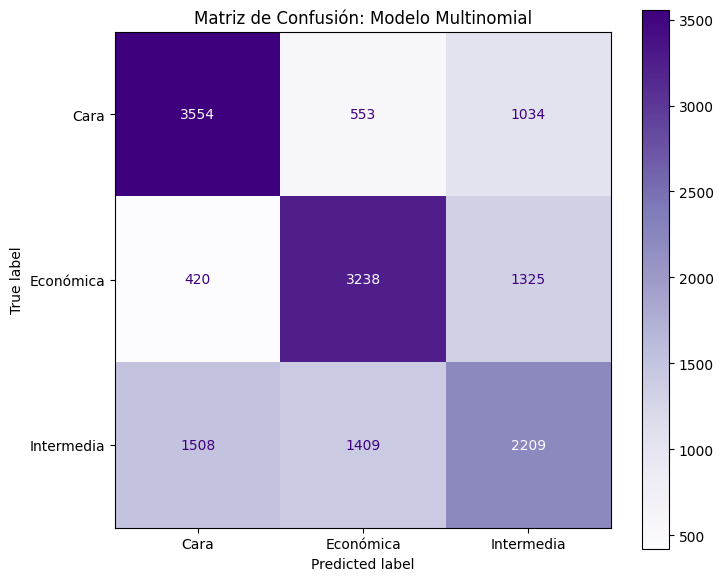

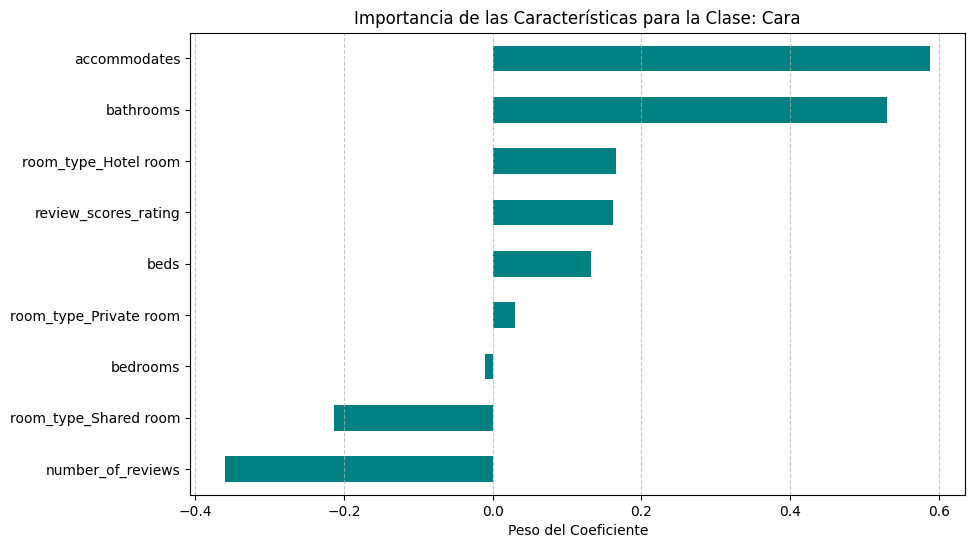

In [6]:
# Actividad 5: Regresión Logística Multinomial (Versión Corregida)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, zero_one_loss
import pandas as pd
import matplotlib.pyplot as plt

# Preparar variable objetivo multiclase
y_train_multi = df_model.loc[X_train_c.index, 'categoria_precio']
y_test_multi = df_model.loc[X_test_c.index, 'categoria_precio']

# Entrenamiento del modelo multinomial
# Nota: Se elimina 'multi_class' ya que las versiones actuales lo detectan automáticamente
multi_model = LogisticRegression(solver='lbfgs', random_state=42, max_iter=1000)
multi_model.fit(X_train_c_scaled, y_train_multi)

# Predicciones y métricas
y_pred_train_multi = multi_model.predict(X_train_c_scaled)
y_pred_multi = multi_model.predict(X_test_c_scaled)
error_train_multi = zero_one_loss(y_train_multi, y_pred_train_multi)
error_test_multi = zero_one_loss(y_test_multi, y_pred_multi)

print("Reporte de Clasificación Multinomial:")
print(classification_report(y_test_multi, y_pred_multi))
print(f"Error entrenamiento: {error_train_multi:.4f}")
print(f"Error prueba: {error_test_multi:.4f}")
print(f"Brecha de error (prueba - entrenamiento): {error_test_multi - error_train_multi:.4f}")

# Visualización 1: Matriz de Confusión Multiclase
fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay.from_predictions(y_test_multi, y_pred_multi, cmap='Purples', ax=ax)
plt.title('Matriz de Confusión: Modelo Multinomial')
plt.show()

# Visualización 2: Importancia de Variables (Coeficientes para la primera clase)
# multi_model.coef_ tiene una fila por cada clase
importancias = pd.Series(multi_model.coef_[0], index=X_train_c.columns)
importancias.sort_values().plot(kind='barh', color='teal', figsize=(10, 6))
plt.title(f'Importancia de las Características para la Clase: {multi_model.classes_[0]}')
plt.xlabel('Peso del Coeficiente')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


### Análisis de Resultados - Ejercicio 5

Para revisar sobreajuste en el modelo multinomial se comparan los errores de entrenamiento y prueba:

* **Error de entrenamiento:** **0.4127**
* **Error de prueba:** **0.4098**
* **Brecha:** **-0.0029**

Dado que ambos errores son prácticamente iguales, **no hay evidencia de overfitting** en el modelo multinomial. El comportamiento sobre datos de entrenamiento y de prueba es muy similar, por lo que el modelo mantiene su capacidad de generalización.

Lo que sí reflejan estos valores es que el problema multiclase es más exigente que los binarios: clasificar simultáneamente propiedades **Económicas**, **Intermedias** y **Caras** introduce más confusión entre categorías vecinas. Aun así, el modelo no está memorizando el entrenamiento; más bien enfrenta una frontera de decisión naturalmente más compleja.

### Curva de aprendizaje - Ejercicio 5

La siguiente curva de aprendizaje muestra el comportamiento del **error** en entrenamiento y prueba para el modelo multinomial. La cercanía entre ambas curvas permite evaluar visualmente si existe o no sobreajuste.

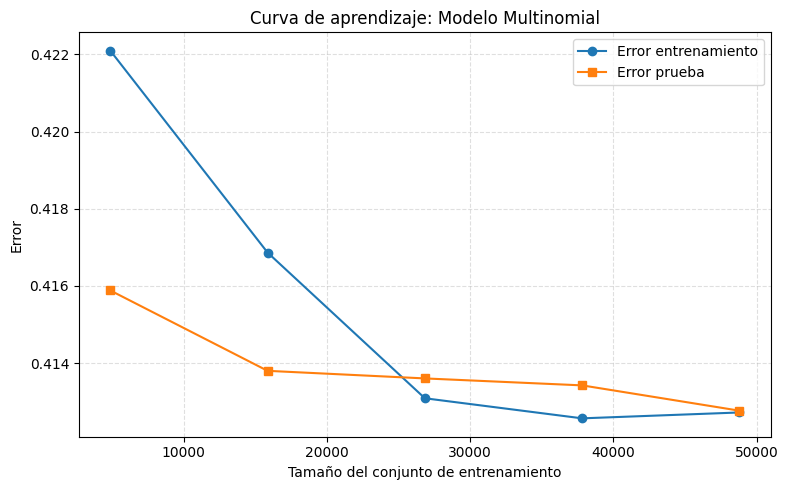

In [7]:
from sklearn.model_selection import learning_curve
from sklearn.metrics import make_scorer, zero_one_loss

error_scorer = make_scorer(zero_one_loss, greater_is_better=False)
train_sizes = np.linspace(0.1, 1.0, 5)

sizes, train_scores, test_scores = learning_curve(
    LogisticRegression(solver='lbfgs', random_state=42, max_iter=1000),
    X_train_c_scaled,
    y_train_multi,
    cv=5,
    train_sizes=train_sizes,
    scoring=error_scorer,
    n_jobs=1
)

train_errors = -train_scores.mean(axis=1)
test_errors = -test_scores.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(sizes, train_errors, marker='o', label='Error entrenamiento')
plt.plot(sizes, test_errors, marker='s', label='Error prueba')
plt.title('Curva de aprendizaje: Modelo Multinomial')
plt.xlabel('Tamaño del conjunto de entrenamiento')
plt.ylabel('Error')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()


### Ejercicio 7: Tuneo del modelo de Regresión Logística

En este inciso se realiza un **tuneo del modelo multinomial** para encontrar la mejor combinación de hiperparámetros de regularización. En particular, se evalúan distintas configuraciones de:

* **`C`**: controla la fuerza de regularización.
* **`penalty`**: tipo de regularización aplicada.
* **`solver`**: algoritmo numérico usado para ajustar el modelo.

Para ello se utiliza **`GridSearchCV`** con validación cruzada de 5 particiones, tomando como métrica principal la exactitud (*accuracy*).

Mejores hiperparámetros encontrados:
{'C': 0.01, 'max_iter': 2000, 'penalty': 'l1', 'solver': 'saga'}
Accuracy promedio en validación cruzada: 0.5879
Accuracy modelo base en prueba: 0.5902
Accuracy modelo tuneado en prueba: 0.5913

Reporte de clasificación - modelo tuneado:
              precision    recall  f1-score   support

        Cara       0.65      0.69      0.67      5141
   Económica       0.62      0.65      0.64      4983
  Intermedia       0.48      0.43      0.46      5126

    accuracy                           0.59     15250
   macro avg       0.59      0.59      0.59     15250
weighted avg       0.59      0.59      0.59     15250



,Modelo,Accuracy en prueba
0,Base multinomial,0.590230
1,Tuneado multinomial,0.591279


/var/folders/rz/77tc4zwd2s56kft6c66tq1l80000gn/T/ipykernel_7887/2504655510.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=comparacion_modelos, x='Modelo', y='Accuracy en prueba', palette='Set2')


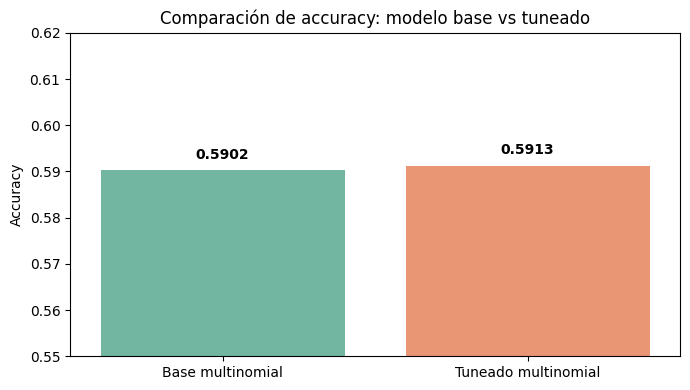

In [8]:
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

warnings.filterwarnings("ignore", message=".*penalty.*deprecated.*")
warnings.filterwarnings("ignore", message=".*l1_ratio.*")

# Modelo base para comparación
modelo_base = LogisticRegression(solver='lbfgs', random_state=42, max_iter=1000)
modelo_base.fit(X_train_c_scaled, y_train_multi)
y_pred_base = modelo_base.predict(X_test_c_scaled)
accuracy_base = accuracy_score(y_test_multi, y_pred_base)

# Malla de hiperparámetros para tuneo
param_grid = [
    {'solver': ['lbfgs', 'newton-cg'], 'penalty': ['l2'], 'C': [0.01, 0.1, 1, 10, 100]},
    {'solver': ['saga'], 'penalty': ['l1', 'l2'], 'C': [0.01, 0.1, 1, 10], 'max_iter': [2000]}
]

grid_search = GridSearchCV(
    estimator=LogisticRegression(random_state=42, max_iter=2000),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=1
)

grid_search.fit(X_train_c_scaled, y_train_multi)
mejor_modelo = grid_search.best_estimator_
y_pred_tuneado = mejor_modelo.predict(X_test_c_scaled)
accuracy_tuneado = accuracy_score(y_test_multi, y_pred_tuneado)

print("Mejores hiperparámetros encontrados:")
print(grid_search.best_params_)
print(f"Accuracy promedio en validación cruzada: {grid_search.best_score_:.4f}")
print(f"Accuracy modelo base en prueba: {accuracy_base:.4f}")
print(f"Accuracy modelo tuneado en prueba: {accuracy_tuneado:.4f}")
print("\nReporte de clasificación - modelo tuneado:")
print(classification_report(y_test_multi, y_pred_tuneado))

comparacion_modelos = pd.DataFrame({
    'Modelo': ['Base multinomial', 'Tuneado multinomial'],
    'Accuracy en prueba': [accuracy_base, accuracy_tuneado]
})
display(comparacion_modelos)

plt.figure(figsize=(7, 4))
ax = sns.barplot(data=comparacion_modelos, x='Modelo', y='Accuracy en prueba', palette='Set2')
plt.title('Comparación de accuracy: modelo base vs tuneado')
plt.ylim(0.55, 0.62)
plt.ylabel('Accuracy')
plt.xlabel('')
for p in ax.patches:
    ax.annotate(f"{p.get_height():.4f}",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', xytext=(0, 6),
                textcoords='offset points', fontweight='bold')
plt.tight_layout()
plt.show()


### Análisis de Resultados - Ejercicio 7

El tuneo encontró como mejor configuración **`solver = saga`**, **`penalty = l1`** y **`C = 0.01`**, lo que implica una regularización relativamente fuerte. Esto sugiere que conviene restringir más los coeficientes del modelo para evitar pesos innecesarios y conservar solo las señales más útiles.

El cambio en desempeño fue **pequeño pero positivo**: el modelo base obtuvo una exactitud en prueba de **0.5902**, mientras que el modelo tuneado alcanzó **0.5913**. Aunque la mejora es modesta, confirma que la regularización ayuda a ajustar ligeramente mejor el modelo sin alterar su estabilidad general.

En consecuencia, el modelo tuneado puede considerarse preferible al modelo base, porque logra el mejor desempeño encontrado en validación cruzada y mantiene una ligera mejora sobre el conjunto de prueba.